# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

# Loading Dataset

In [2]:
df = pd.read_csv('../Data/hotel_bookings 2.csv')

# Exploratory Data Analysis and Data Cleaning

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,3/7/2015


In [4]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,6/9/2017
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,7/9/2017
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,7/9/2017
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,7/9/2017
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,7/9/2017


In [5]:
df.shape

(119390, 32)

In [6]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

#### Change Datatype str to datetime

In [8]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'], dayfirst = True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  str           
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  str           
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119386 non-null  float64       
 11

In [9]:
df.describe(include = 'object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166


### Extract object with their respacted unique values

In [10]:
for col in df.describe(include = 'object'):
    print(col)
    print(df[col].unique())
    print('-'*70)


hotel
<StringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str
----------------------------------------------------------------------
arrival_date_month
<StringArray>
[     'July',    'August', 'September',   'October',  'November',  'December',
   'January',  'February',     'March',     'April',       'May',      'June']
Length: 12, dtype: str
----------------------------------------------------------------------
meal
<StringArray>
['BB', 'FB', 'HB', 'SC', 'Undefined']
Length: 5, dtype: str
----------------------------------------------------------------------
country
<StringArray>
['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA',   nan, 'ROU', 'NOR', 'OMN',
 ...
 'ATA', 'GTM', 'ASM', 'MRT', 'NCL', 'KIR', 'SDN', 'ATF', 'SLE', 'LAO']
Length: 178, dtype: str
----------------------------------------------------------------------
market_segment
<StringArray>
[       'Direct',     'Corporate',     'Online TA', 'Offline TA/TO',
 'Complementary',        'Groups',     'Undefined',      'A

### checking missing values

In [11]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

### Removing missing values

In [12]:
df.drop(['agent','company'], axis = 1, inplace = True)
df.dropna(inplace = True)

In [13]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [14]:
df.shape

(118898, 30)

### Summary Statistic for Numeral Columns

In [15]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898
mean,0.371352,104.311435,2016.157656,27.166555,15.800880,0.928897,2.502145,1.858391,0.104207,0.007948,0.032011,0.087142,0.131634,0.221181,2.330754,102.003243,0.061885,0.571683,2016-07-30 07:37:53.336809
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483168,106.903309,0.707459,13.589971,8.780324,0.996216,1.900168,0.578576,0.399172,0.097380,0.176029,0.845869,1.484672,0.652785,17.630452,50.485862,0.244172,0.792678,NaN


### Ploting / Detacting Outlier - in adr

<Axes: >

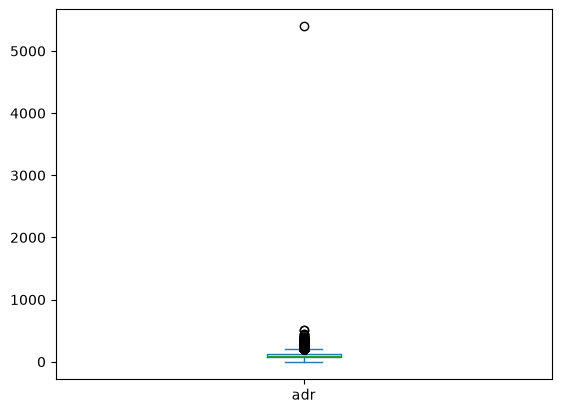

In [16]:
df['adr'].plot(kind = 'box')

### Removing Outlier

In [17]:
df = df[df['adr'] < 5000]

In [18]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897
mean,0.371347,104.312018,2016.157657,27.166674,15.800802,0.928905,2.502157,1.858390,0.104208,0.007948,0.032011,0.087143,0.131635,0.221175,2.330774,101.958683,0.061885,0.571688,2016-07-30 07:39:51.289940
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,510.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483167,106.903570,0.707462,13.589966,8.780321,0.996217,1.900171,0.578578,0.399174,0.097381,0.176030,0.845872,1.484678,0.652784,17.630525,48.091199,0.244173,0.792680,NaN


# Data Analysis and Visualization

## Step 1 — Overall Cancellation Rate

In [19]:
print(df['is_canceled'].value_counts())

is_canceled
0    74745
1    44152
Name: count, dtype: int64


### Calculate the cancellation rate

In [20]:
# print(df['is_canceled'].value_counts(normalize = True))

cancellation_rate = df['is_canceled'].mean() * 100
print(f"Overall cancellation rate: {cancellation_rate:.2f}%")

Overall cancellation rate: 37.13%


### Creating a small Summary Table

In [21]:
cancellation_summary = (
    df["is_canceled"]
    .value_counts()
    .rename(index={0: "Not Canceled", 1: "Canceled"})
    .reset_index()
)

cancellation_summary.columns = ["Booking Status", "Bookings"]

cancellation_summary["Percentage"] = (
    cancellation_summary["Bookings"] / len(df) * 100
)

cancellation_summary

,Booking Status,Bookings,Percentage
0,Not Canceled,74745,62.865337
1,Canceled,44152,37.134663


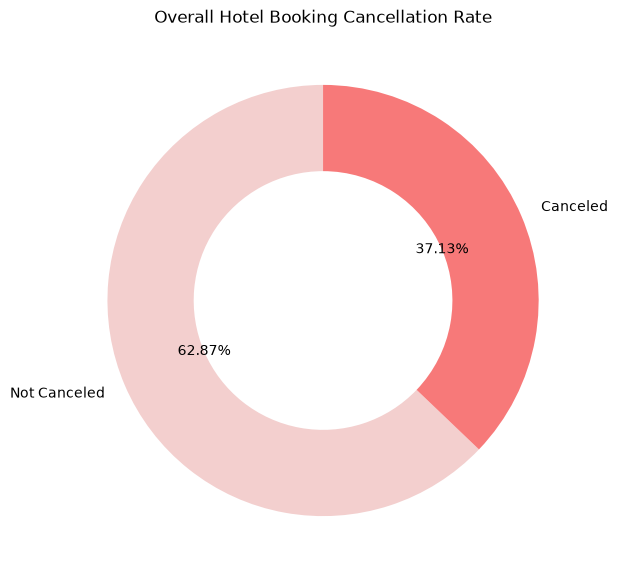

In [66]:
light_palette = ["#F3CFCE", "#F2B1B1", "#F09393", "#F77979", "#ED5757"]

status_counts = df["is_canceled"].value_counts()
labels = ["Not Canceled", "Canceled"]

plt.figure(figsize=(7, 7) )
plt.pie(
    status_counts,
    labels=labels,
    autopct="%1.2f%%",
    startangle=90,
    wedgeprops={"width": 0.4},
    colors = light_palette[::3]
)

plt.title("Overall Hotel Booking Cancellation Rate")
plt.show()

### Finding

**Finding:** The overall cancellation rate is 37.04%, meaning approximately 37.13% of bookings in the dataset were canceled, while 62.87% were not canceled.

### Business interpretation

**Business Interpretation:** A cancellation rate of approximately 37.13% represents a substantial proportion of bookings that may affect room occupancy and expected revenue. Therefore, identifying the characteristics associated with canceled bookings is important for developing targeted cancellation-reduction strategies.

### Next step

**Next Step:** To identify the key factors associated with cancellations, the analysis will examine cancellation rates across hotel type, ADR, lead time, deposit type, market segment, seasonality, and other booking characteristics.

## Step 2 — cancellation rate by hotel

In [67]:
df[['hotel','is_canceled']].head()

,hotel,is_canceled
0,Resort Hotel,0
1,Resort Hotel,0
2,Resort Hotel,0
3,Resort Hotel,0
4,Resort Hotel,0


In [68]:
cancellation_rate_by_hotel = (
    df.groupby('hotel')['is_canceled']
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name = 'cancellation_rate')
)
# cancellation_rate_by_hotel

In [69]:
cancellation_rate_by_hotel.columns = ['Hotel Type', 'Cancellation Rate %']
cancellation_rate_by_hotel

,Hotel Type,Cancellation Rate %
0,City Hotel,41.71
1,Resort Hotel,27.98


### Calculate the difference

In [70]:
rate_difference = (
    cancellation_rate_by_hotel['Cancellation Rate %'].max()
    -cancellation_rate_by_hotel['Cancellation Rate %'].min() 
)
rate_difference # 13.73 percentage points higher

np.float64(13.73)

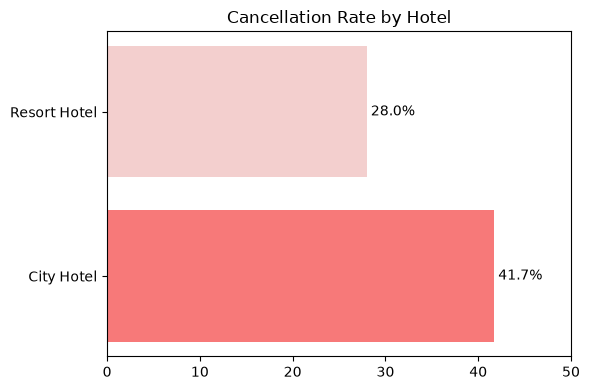

In [71]:
# Prepare data
status_counts = df.groupby("hotel")["is_canceled"].mean() * 100
labels = status_counts.index  

light_palette = ["#F3CFCE", "#F2B1B1", "#F09393", "#F77979", "#ED5757"]

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.barh(labels, status_counts, color=light_palette[::3][::-1])

ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_xlim(0, max(status_counts) * 1.2)

plt.title('Cancellation Rate by Hotel')
plt.tight_layout()
plt.show()

## Step 3 — Cancellation Rate by Lead Time

In [72]:
df[['lead_time','is_canceled']].head()

,lead_time,is_canceled
0,342,0
1,737,0
2,7,0
3,13,0
4,14,0


### Create the Lead Time Groups

In [73]:
bins = [-1, 7, 30, 90, 180 , float('inf')]

labels = [
    '0 - 7 days',
    '8 - 30 days',
    '31 - 90 days',
    '91 - 180 days',
    '180+ days'
]

df['lead_time_groups'] = pd.cut(
    df['lead_time'],
    bins = bins,
    labels = labels
)

### Calculate Cancellation Rate by lead time

In [74]:
lead_time_summary = (
    df.groupby('lead_time_groups',observed=False)['is_canceled']
        .mean()
        .mul(100)
        .round(2)
        .reset_index(name = 'cancellation_rate')
)
lead_time_summary

,lead_time_groups,cancellation_rate
0,0 - 7 days,9.66
1,8 - 30 days,27.92
2,31 - 90 days,37.71
3,91 - 180 days,44.75
4,180+ days,56.98


### Calculate the Difference

In [75]:
lead_time_difference = (
    lead_time_summary['cancellation_rate'].max()
    - lead_time_summary['cancellation_rate'].min()
)
lead_time_difference

np.float64(47.31999999999999)

### Cancellation Rate by lead time

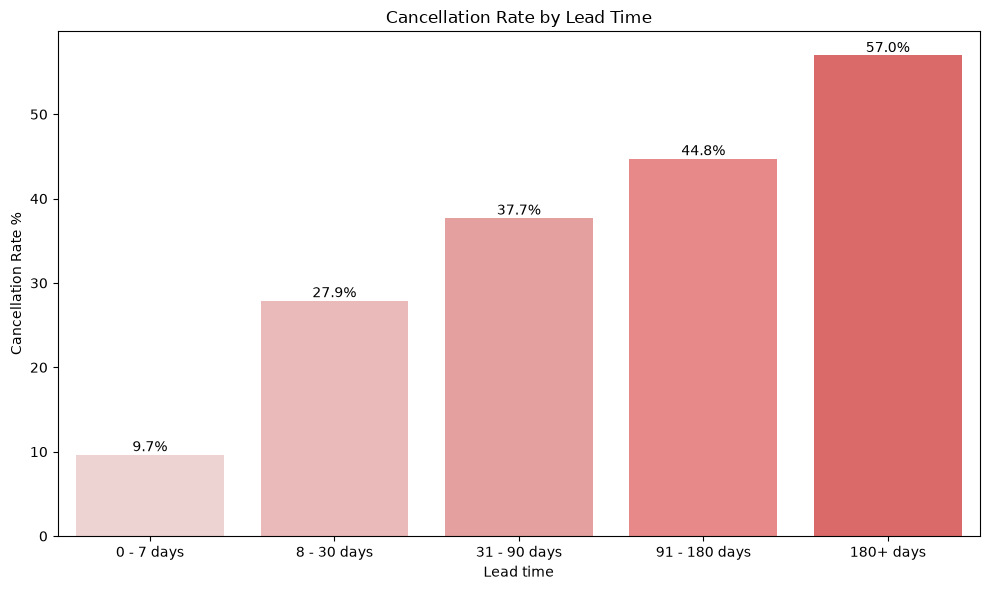

In [76]:
plt.figure(figsize = (10, 6))
ax = sns.barplot(
            data = lead_time_summary,
            x = 'lead_time_groups',
            y = 'cancellation_rate',
            palette= sns.color_palette(light_palette, n_colors=len(lead_time_summary)) 
        )
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
    
plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead time')
plt.ylabel('Cancellation Rate %')

plt.tight_layout()
plt.show()


#### Interpretation

Cancellation rate increases consistently as lead time increases. Bookings made **0–7 days before arrival have a cancellation rate of 9.7%**, while bookings made **181+ days in advance have a cancellation rate of 57.0%**. This represents a difference of **47.31 percentage points**.

The results indicate a strong positive association between longer lead times and booking cancellations. Customers who book significantly further in advance appear to have a higher likelihood of canceling their reservations.

From a business perspective, hotels should pay particular attention to long-lead bookings because they represent a higher cancellation-risk segment. However, this analysis identifies an association rather than proving that longer lead time directly causes cancellations.


## Step 4 — Cancellation Rate by Deposit Type

#### Business Question
How does cancellation rate vary by deposit type?

### Analysis
1. Group bookings by deposit type

#### Deposit Type Cancellation Summary Table

In [77]:
deposit_cancellation = (
    df.groupby('deposit_type')['is_canceled']
    .agg(
          total_bookings='count',
          canceled_bookings='sum',
          cancellation_rate='mean'
      )
    .reset_index()
)
deposit_cancellation['cancellation_rate'] = (
    deposit_cancellation['cancellation_rate'] * 100
).round(2)

deposit_cancellation = deposit_cancellation.sort_values(
                        by = 'cancellation_rate'
)

deposit_cancellation

,deposit_type,total_bookings,canceled_bookings,cancellation_rate
2,Refundable,162,36,22.22
0,No Deposit,104163,29637,28.45
1,Non Refund,14572,14479,99.36


In [78]:
deposit_cancellation.style.format({
    'cancellation_rate': '{:.2f}%'
})

,deposit_type,total_bookings,canceled_bookings,cancellation_rate
2,Refundable,162,36,22.22%
0,No Deposit,104163,29637,28.45%
1,Non Refund,14572,14479,99.36%


### Cancellation Rate by Deposit Type

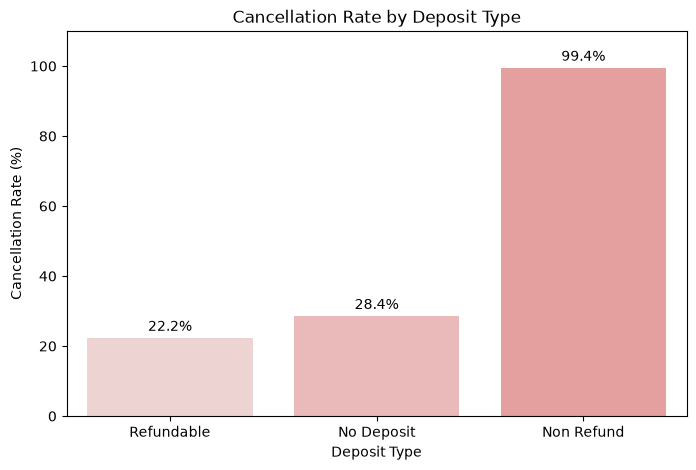

In [79]:

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=deposit_cancellation,
    x='deposit_type',
    y='cancellation_rate',
    palette= sns.color_palette( light_palette , n_colors=len(deposit_cancellation)) 
)

plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 110)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.show()

### Investigate the unusually high Non Refund cancellation rate

#### step 4.1 : Check the sample size

In [80]:
non_refund_check = (
    df.groupby('deposit_type')['is_canceled']
     .agg(Booking = 'count',
         Cancelled = 'sum', 
         cancellation_rate = 'mean')
      .reset_index()
)

non_refund_check['cancellation_rate'] = (
    non_refund_check['cancellation_rate'] * 100
).round(2)

non_refund_check


,deposit_type,Booking,Cancelled,cancellation_rate
0,No Deposit,104163,29637,28.45
1,Non Refund,14572,14479,99.36
2,Refundable,162,36,22.22


#### step 4.2: Look directly at the Non Refund bookings

In [81]:
non_refund = df[df['deposit_type'] == 'Non Refund']

non_refund['is_canceled'].value_counts()


is_canceled
1    14479
0       93
Name: count, dtype: int64

#### step 4.3: Compare Non Refund cancellation rate by hotel

In [82]:
non_refund_hotel = (
    df[df['deposit_type'] == 'Non Refund']
    .groupby('hotel')['is_canceled']
    .agg(Booking = 'count',
         Cancelled = 'sum', 
         cancellation_rate = 'mean')
    .reset_index()
)

non_refund_hotel['cancellation_rate'] = (
    non_refund_hotel['cancellation_rate'] * 100
).round(2)

non_refund_hotel


,hotel,Booking,Cancelled,cancellation_rate
0,City Hotel,12853,12829,99.81
1,Resort Hotel,1719,1650,95.99


#### step 4.4: Check Non Refund cancellation rate by Market Segment

In [83]:
non_refund_segment = (
    df[df['deposit_type'] == 'Non Refund']
    .groupby('market_segment')['is_canceled']
    .agg(Booking = 'count',
         Cancelled = 'sum', 
         cancellation_rate = 'mean')
    .reset_index()
)

non_refund_segment['cancellation_rate'] = (
    non_refund_segment['cancellation_rate'] * 100
).round(2)

non_refund_segment.sort_values(
    'cancellation_rate',
    ascending=False
)


,market_segment,Booking,Cancelled,cancellation_rate
3,Offline TA/TO,4991,4988,99.94
2,Groups,9172,9110,99.32
4,Online TA,56,53,94.64
0,Corporate,334,312,93.41
1,Direct,19,16,84.21


#### step 4.5: Check Non Refund cancellation rate by Distribution Channel

In [84]:
non_refund_channel = (
    df[df['deposit_type'] == 'Non Refund']
    .groupby('distribution_channel')['is_canceled']
    .agg(Booking = 'count',
         Cancelled = 'sum', 
         cancellation_rate = 'mean')
    .reset_index()
)

non_refund_channel['cancellation_rate'] = (
    non_refund_channel['cancellation_rate'] * 100
).round(2)

non_refund_channel.sort_values(
    'cancellation_rate',
    ascending=False
)


,distribution_channel,Booking,Cancelled,cancellation_rate
2,TA/TO,13636,13583,99.61
1,Direct,398,388,97.49
0,Corporate,538,508,94.42


### Key finding
The 99.36% rate is supported by a substantial sample and remains exceptionally high across hotel types, market segments, and distribution channels, with the strongest concentration among TA/TO and Group bookings.

In [85]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'lead_time_groups'],
      dtype='str')

## Step 5: Cancellation Rate by Booking Channel

In [86]:
channel_cancellation = (
    df.groupby('distribution_channel')
    .agg(
        bookings = ('is_canceled','count'),
        cancelled = ('is_canceled', 'sum')
    )
    .reset_index()
)
channel_cancellation['not_cancelled'] = (
    channel_cancellation['bookings']
    - channel_cancellation['cancelled']
)

channel_cancellation['cancellation_rate'] = (
    channel_cancellation['cancelled']
    / channel_cancellation['bookings']
    * 100
).round(2)

channel_cancellation = channel_cancellation.sort_values(
    'cancellation_rate',
    ascending = False
)

channel_cancellation

,distribution_channel,bookings,cancelled,not_cancelled,cancellation_rate
3,TA/TO,97729,40118,57611,41.05
0,Corporate,6491,1454,5037,22.40
2,GDS,193,37,156,19.17
1,Direct,14483,2543,11940,17.56
4,Undefined,1,0,1,0.00


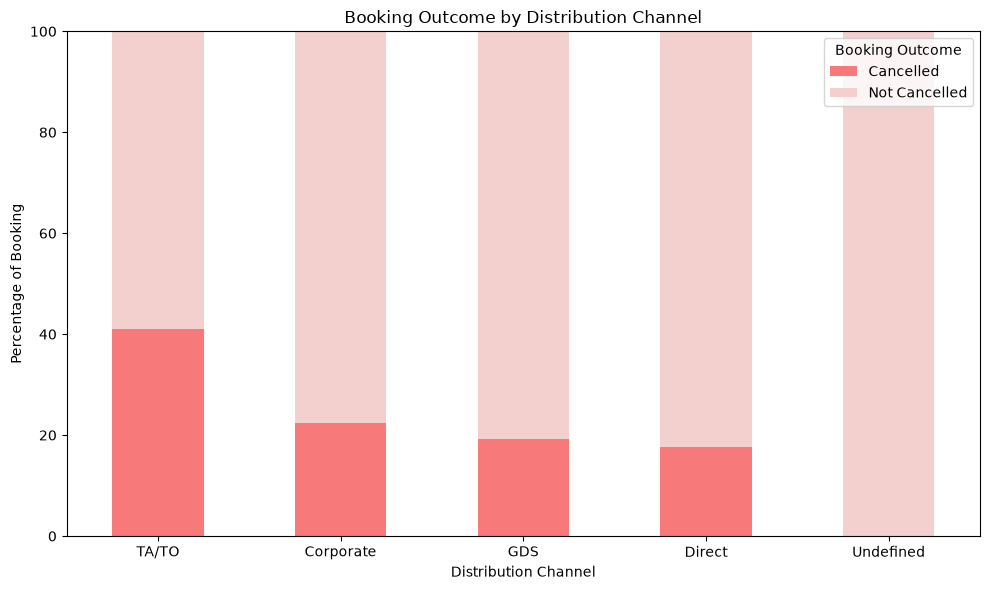

In [87]:
channel_plot = channel_cancellation.copy()

channel_plot['cancelled_pct'] = (
    channel_plot['cancelled'] /
    channel_plot['bookings'] * 100
)

channel_plot['not_cancelled_pct'] = (
    channel_plot['not_cancelled'] / 
    channel_plot['bookings'] * 100
)
# Plot

ax = channel_plot.set_index('distribution_channel')[
    ['cancelled_pct','not_cancelled_pct']
].plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6),
    color = light_palette[::3][::-1]
)

plt.title('Booking Outcome by Distribution Channel')
plt.xlabel('Distribution Channel')
plt.ylabel('Percentage of Booking')
plt.xticks(rotation = 0)
plt.ylim(0, 100)
plt.legend(
    title = 'Booking Outcome',
    labels = ['Cancelled', 'Not Cancelled']
)

plt.tight_layout()
plt.show()

## Step 6: Overall Cancellation Rate by Market Segment

In [88]:
market_segment_cancellation = (
    df.groupby('market_segment')
    .agg(
        bookings = ('is_canceled','count'),
        cancelled = ('is_canceled', 'sum')
    ).reset_index()
)
market_segment_cancellation['not_cancelled']=(
    market_segment_cancellation['bookings']
    - market_segment_cancellation['cancelled']
)
market_segment_cancellation['cancellation_rate'] = (
    market_segment_cancellation['cancelled']
    / market_segment_cancellation['bookings']
    * 100
).round(2)
market_segment_cancellation = market_segment_cancellation.sort_values(
    'cancellation_rate',
    ascending = False
)
market_segment_cancellation

,market_segment,bookings,cancelled,not_cancelled,cancellation_rate
4,Groups,19806,12097,7709,61.08
6,Online TA,56402,20738,35664,36.77
5,Offline TA/TO,24159,8277,15882,34.26
0,Aviation,237,52,185,21.94
2,Corporate,5111,978,4133,19.14
3,Direct,12448,1920,10528,15.42
1,Complementary,734,90,644,12.26


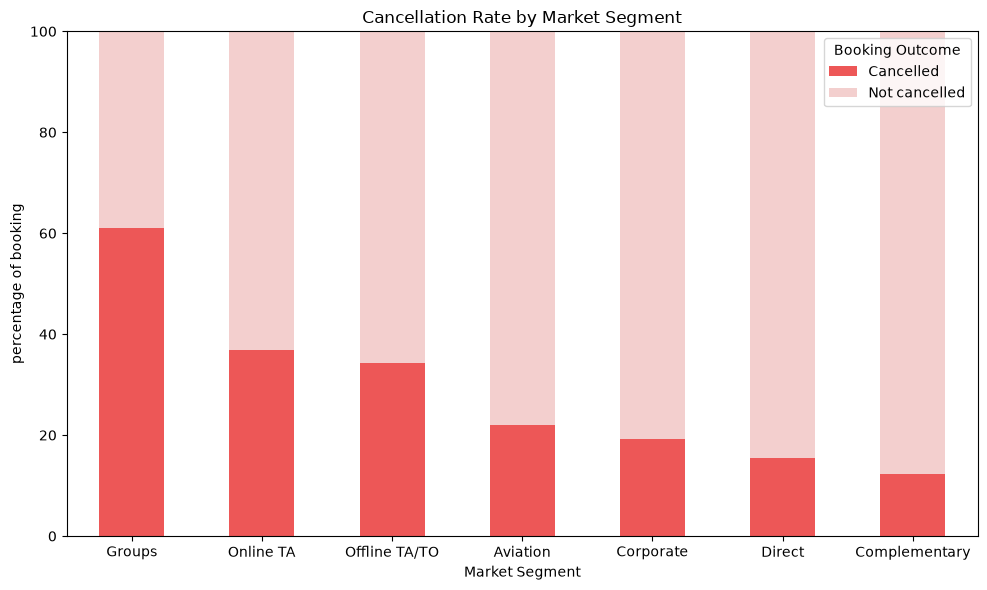

In [96]:
market_plot = market_segment_cancellation.copy()

market_plot['cancelled_pct'] = (
    market_plot['cancelled'] /
    market_plot['bookings'] * 100
)

market_plot['not_cancelled_pct'] = (
    market_plot['not_cancelled'] /
    market_plot['bookings'] * 100
)

# plot

ax = market_plot.set_index('market_segment')[
    ['cancelled_pct','not_cancelled_pct']
].plot(
    kind = 'bar',
    stacked = True,
    figsize=(10,6),
    color = light_palette[::2][::-2]
)
plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('percentage of booking')
plt.xticks(rotation = 0)
plt.ylim(0, 100)
plt.legend(
    title = 'Booking Outcome',
    labels = ['Cancelled','Not cancelled']
)
plt.tight_layout()
plt.show()